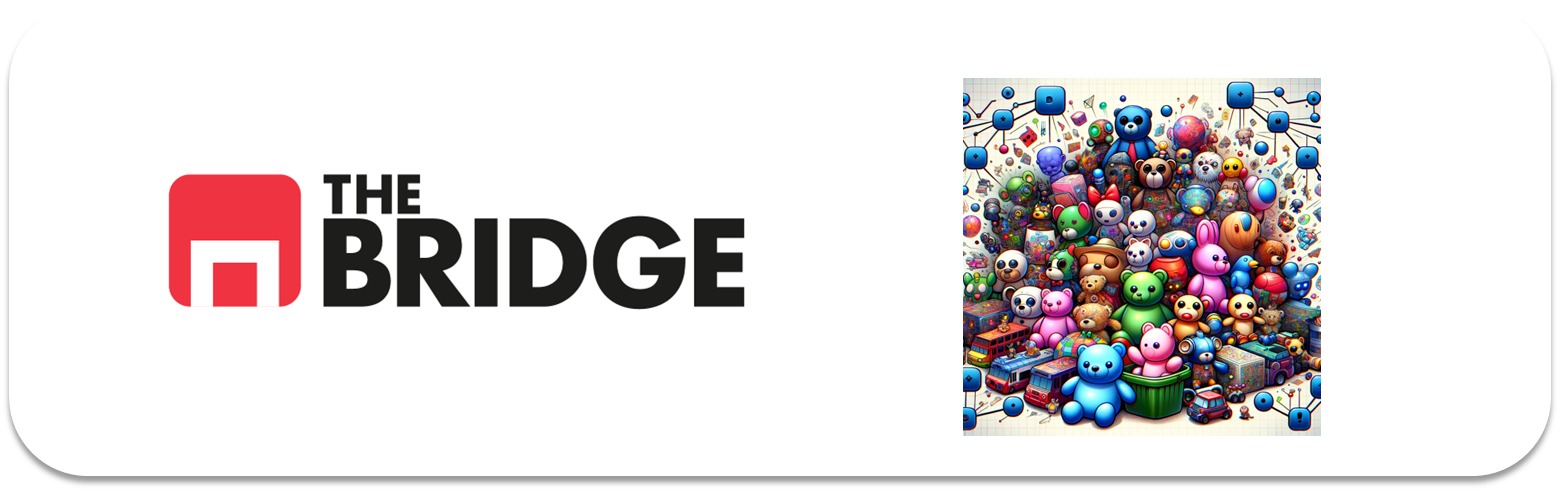

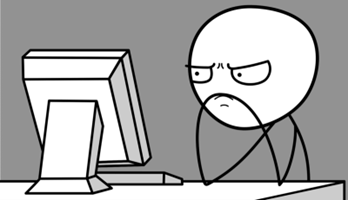

Para ejercitarte y afianzar lo aprendido sobre **K-Means**, completa los siguientes ejercicios. Recuerda que necesitarás datos que están en el directorio data que acompaña al notebook (búscalo en el repositorio de ejercicios)
  
La solución a los mismos las tienes ya, intenta no mirarlos de primeras pero no dejes de hacerlo cuando hayas terminado por si te pudieran aportar.

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

### Entendiendo el problema de negocio

En este notebook vamos a hacer un análisis de datos tirando de clusterizaciones para evaluar si existen grupos en nuestros productos, en este caso medicamentos, y posteriormente poder etiquetarlos. Poseemos información como rating, efectividad, efectos secundarios, entre otros.

### Ejercicio 1

Importa los datos, "./data/drugLibTrain_raw.tsv", que contiene un dataset con diferentes fármacos, sus efectos y ratings de los clientes de dichos fármacos. Realiza una inspección preliminar y quita las columnas que consideres innecesarias.

In [2]:
import os
os.listdir("data")


['drugLibTrain_raw.tsv']

In [3]:
os.listdir("data")


['drugLibTrain_raw.tsv']

In [4]:
df = pd.read_csv("data/drugLibTrain_raw.tsv", sep="\t")

df.head()


,Unnamed: 0,urlDrugName,rating,effectiveness,sideEffects,condition,benefitsReview,sideEffectsReview,commentsReview
0,2202,enalapril,4,Highly Effective,Mild Side Effects,management of congestive heart failure,slowed the progression of left ventricular dys...,"cough, hypotension , proteinuria, impotence , ...","monitor blood pressure , weight and asses for ..."
1,3117,ortho-tri-cyclen,1,Highly Effective,Severe Side Effects,birth prevention,Although this type of birth control has more c...,"Heavy Cycle, Cramps, Hot Flashes, Fatigue, Lon...","I Hate This Birth Control, I Would Not Suggest..."
2,1146,ponstel,10,Highly Effective,No Side Effects,menstrual cramps,I was used to having cramps so badly that they...,Heavier bleeding and clotting than normal.,I took 2 pills at the onset of my menstrual cr...
3,3947,prilosec,3,Marginally Effective,Mild Side Effects,acid reflux,The acid reflux went away for a few months aft...,"Constipation, dry mouth and some mild dizzines...",I was given Prilosec prescription at a dose of...
4,1951,lyrica,2,Marginally Effective,Severe Side Effects,fibromyalgia,I think that the Lyrica was starting to help w...,I felt extremely drugged and dopey. Could not...,See above


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3107 entries, 0 to 3106
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Unnamed: 0         3107 non-null   int64
 1   urlDrugName        3107 non-null   str  
 2   rating             3107 non-null   int64
 3   effectiveness      3107 non-null   str  
 4   sideEffects        3107 non-null   str  
 5   condition          3106 non-null   str  
 6   benefitsReview     3089 non-null   str  
 7   sideEffectsReview  3032 non-null   str  
 8   commentsReview     3095 non-null   str  
dtypes: int64(2), str(7)
memory usage: 218.6 KB


In [6]:
df.columns = df.columns.str.strip()

cols_to_drop = [
    "Unnamed: 0",
    "urlDrugName",
    "benefitsReview",
    "sideEffectsReview",
    "commentsReview"
]

df = df.drop(columns=cols_to_drop)

In [7]:
df.head()

,rating,effectiveness,sideEffects,condition
0,4,Highly Effective,Mild Side Effects,management of congestive heart failure
1,1,Highly Effective,Severe Side Effects,birth prevention
2,10,Highly Effective,No Side Effects,menstrual cramps
3,3,Marginally Effective,Mild Side Effects,acid reflux
4,2,Marginally Effective,Severe Side Effects,fibromyalgia


### Ejercicio 2: MiniEDA

Como es un problema no supervisado (vamos a intentar agrupar los medicamentos sin tener una referencia o target inicial), no hay split, vamos directos al miniEDA. Analiza qué variables son descartables en función de su porcentaje de cardinalidad. Es decir obten la cardinalidad y su porcentaje para cada posible feature y crea un dataset nuevo descartando las features que creas conveniente. NOTA: Como simplificación, descarta la columna con url.

In [8]:
# He descartado las columnas que no aportan información relevante para el clustering, 
# como el identificador de la fila, el nombre del medicamento y las reseñas de beneficios, efectos secundarios y comentarios. 
# Estas columnas no contienen características numéricas que puedan ser utilizadas para agrupar los datos de manera efectiva. 
# Al eliminar estas columnas, nos centramos en las características que pueden ayudar a identificar patrones y similitudes entre los medicamentos.

### Ejercicio 3

Construye un train set (llámalo X) sólo con las features que hayas seleccionado del ejercicio anterior (es decir las que no hayas descartado como posibles features) 

In [9]:
df.isna().sum()

rating           0
effectiveness    0
sideEffects      0
condition        1
dtype: int64

In [10]:
df["condition"] = df["condition"].fillna("Unknown")


In [11]:
X = df.copy()
X.head()
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 3107 entries, 0 to 3106
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   rating         3107 non-null   int64
 1   effectiveness  3107 non-null   str  
 2   sideEffects    3107 non-null   str  
 3   condition      3107 non-null   str  
dtypes: int64(1), str(3)
memory usage: 97.2 KB


In [12]:
X.isna().sum()

rating           0
effectiveness    0
sideEffects      0
condition        0
dtype: int64

### Ejercicio 4 

Trasforma las features que consideres necesario (categóricas y numéricas) y luego aplica el escalado que consideres necesario.

In [13]:
cat_cols = X.select_dtypes(include=["object"]).columns.to_list()
cat_cols


/var/folders/0g/ltyf2qv91t9_1979pghhp9fh0000gn/T/ipykernel_58485/2157992096.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include=["object"]).columns.to_list()


['effectiveness', 'sideEffects', 'condition']

In [14]:
num_cols = X.select_dtypes(include=["number"]).columns.to_list()
num_cols

['rating']

In [15]:
X["condition"].nunique()

1427

In [16]:
top_conditions = X["condition"].value_counts().nlargest(20).index

X["condition"] = X["condition"].where(
    X["condition"].isin(top_conditions),
    "Other"
)


In [17]:
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
X_encoded = encoder.fit_transform(X[cat_cols])
X_encoded.shape

(3107, 31)

In [18]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X[num_cols])

### Ejercicio 5: Otención de K, aproximación visual

Analiza la relación entre features (con scatter plots) una vez transformadas para comprobar si existe visualmente algún indicio del número de clústeres que podríamos estar buscando. Por otro lado este análisis nos puede hacer descartar alguna feature o generar una nueva

In [19]:
X_scaled_df = pd.DataFrame(
    X_scaled,
    columns=num_cols,
    index=X.index
)

X_encoded_df = pd.DataFrame(
    X_encoded,
    columns=encoder.get_feature_names_out(cat_cols),
    index=X.index
)

X_prepared = pd.concat([X_scaled_df, X_encoded_df], axis=1)

In [20]:
from sklearn.cluster import KMeans

inertia = []
k_values = range(1, 11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    clusters = kmeans.fit_predict(X_prepared)
    inertia.append(kmeans.inertia_)

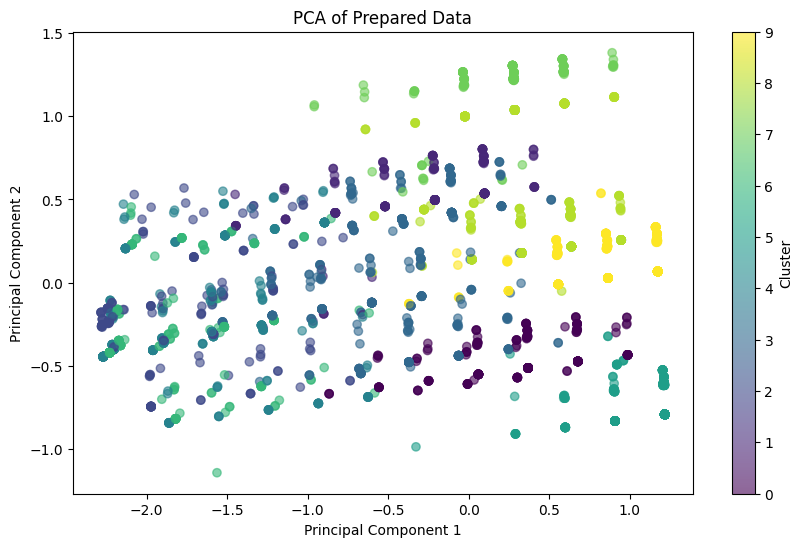

In [21]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_prepared)

plt.figure(figsize=(10, 6))
plt.scatter(X_pca[:,0], X_pca[:,1], alpha=0.6, c=clusters, cmap="viridis")
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA of Prepared Data')
plt.colorbar(label='Cluster')
plt.show();

### Ejercicio 6: Obtención de K, método del codo

Evalua diferentes valores K y escoge uno a partir del método del codo/elbow de inercia.

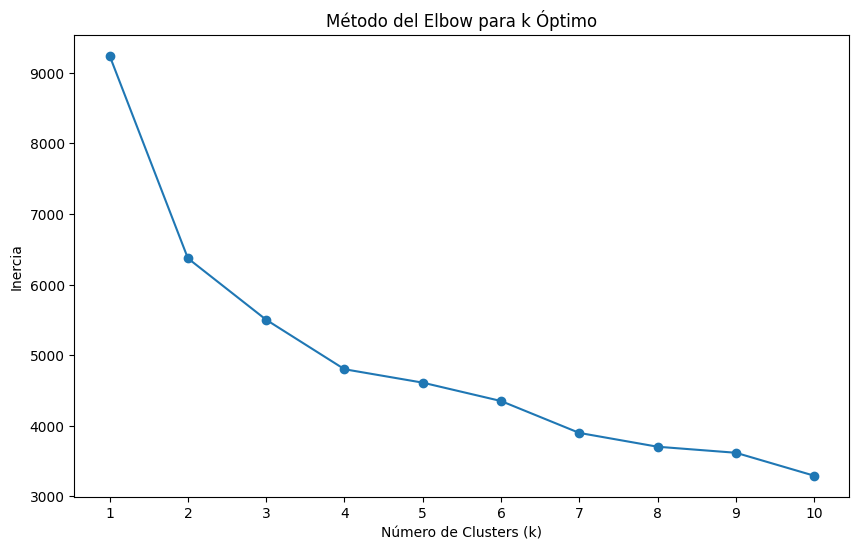

In [22]:
plt.figure(figsize=(10, 6))
plt.plot(k_values, inertia, marker = "o")
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Inercia')
plt.title('Método del Elbow para k Óptimo')
plt.xticks(k_values)
plt.show();

### Ejercicio 7: Obtención de K, Score de Silueta

Comprueba el ajuste de k obteniendo el k que maximiza el score de silueta y pinta un gráfico de la evolución de dicho score con k. Usa los valores de k que hayas probado en el ejercicio anterior.

In [23]:
from sklearn.metrics import silhouette_score

silhouette_scores = {}

for k in [2,3,4,5,6]:
    kmeans = KMeans(n_clusters=k, random_state=42)
    clusters = kmeans.fit_predict(X_prepared)
    score = silhouette_score(X_prepared, clusters)
    
    silhouette_scores[k] = {
        "model": kmeans,
        "labels": clusters,
        "silhouette": score
    }
    
    print(f"k={k} - Silhouette Score: {score:.4f}")


k=2 - Silhouette Score: 0.3273
k=3 - Silhouette Score: 0.2349
k=4 - Silhouette Score: 0.2525
k=5 - Silhouette Score: 0.2319
k=6 - Silhouette Score: 0.2424


### Ejercicio 8: Obtención de K, diagrama de silueta

Para completar el estudio de k, muestra el diagramde silueta para k=2,3,4,5 y decide con este datos y los anteriores el valor de k a probar. NOTA: En la realidad, podríamos probar perfectamente k=2 y k=3 y luego que "Negocio" decidiera cuál le es más útil, aquí lo completamos por practicar todo lo aprendido

In [24]:
# ^

### Ejercico 9:

En general, una diferencia entre el proceso de construcción de un modelo no supervisado y un supervisado es que el ajuste de algunos hiperparámetros (como el número de clústeres) es anterior a la construcción del modelo. Por eso, construye un K-means para el valor (o valores) de K escogidos.

In [25]:
best_k = 2

kmeans = KMeans(n_clusters=best_k, random_state=42)
kmeans.fit(X_prepared)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",2
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",42
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [26]:
second_best_k = 3

kmeans_second = KMeans(n_clusters=second_best_k, random_state=42)
kmeans_second.fit(X_prepared)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",3
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",42
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


### Ejercicio 10

Vamos a comprobar resultados, analizando los valores medios y distribución de cada uno de los clústeres para el k óptimo. Si tuvieras más de un posible valor de k a probar, analiza aquí el de mayor score de silueta. Y utiliza el siguiente ejercicio para el otro. Además de hacer un describe de las features por clúster, pinta estos con un pairplot considerando sideEffects y rating como x e y (o viceversa) y el clúster como hue (color). Compara el resultado con los clústeres sugeridos en el ejercicio 5.

In [27]:
df['cluster_k2'] = kmeans.labels_

In [28]:
df.groupby('cluster_k2').mean(numeric_only=True)


,rating
cluster_k2,
0,8.607286
1,2.795561


In [29]:
df['cluster_k3'] = kmeans_second.labels_

In [30]:
df.groupby('cluster_k3').mean(numeric_only=True)

,rating,cluster_k2
cluster_k3,,
0,8.277263,0.004989
1,2.776207,1.000000
2,9.120468,0.000000


In [31]:
df.head(20)

,rating,effectiveness,sideEffects,condition,cluster_k2,cluster_k3
0,4,Highly Effective,Mild Side Effects,management of congestive heart failure,1,1
1,1,Highly Effective,Severe Side Effects,birth prevention,1,1
2,10,Highly Effective,No Side Effects,menstrual cramps,0,2
3,3,Marginally Effective,Mild Side Effects,acid reflux,1,1
4,2,Marginally Effective,Severe Side Effects,fibromyalgia,1,1
5,1,Ineffective,Severe Side Effects,hair loss,1,1
6,9,Highly Effective,Mild Side Effects,add,0,0
7,10,Considerably Effective,No Side Effects,depression,0,2
8,10,Highly Effective,No Side Effects,panic disorder,0,2
9,1,Ineffective,Extremely Severe Side Effects,allergies,1,1


In [34]:
df['sideEffects'].isna().sum()

np.int64(0)

In [35]:
df["sideEffects"].dtype

<StringDtype(storage='python', na_value=nan)>

In [37]:
table = pd.crosstab(df['cluster_k2'], df['sideEffects'], normalize='index')
table_percent = table * 100
table_percent

sideEffects,Extremely Severe Side Effects,Mild Side Effects,Moderate Side Effects,No Side Effects,Severe Side Effects
cluster_k2,,,,,
0,0.310973,41.803643,16.570413,37.983119,3.331853
1,19.626168,9.112150,28.154206,8.761682,34.345794


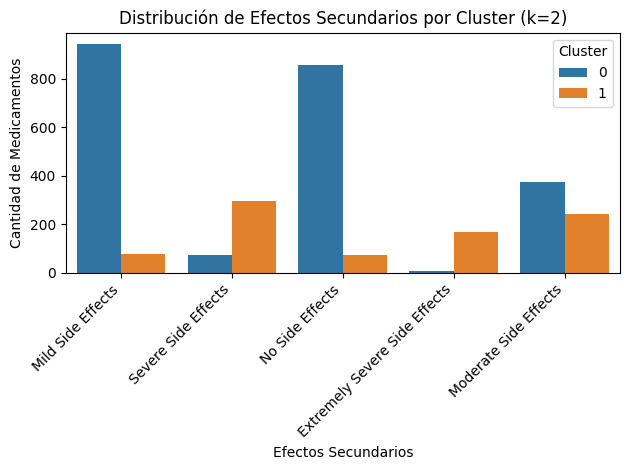

In [40]:
sns.countplot(x='sideEffects', hue='cluster_k2', data=df)
plt.title('Distribución de Efectos Secundarios por Cluster (k=2)')
plt.xlabel('Efectos Secundarios')
plt.ylabel('Cantidad de Medicamentos')
plt.legend(title='Cluster')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show();

### Ejercicio 11, EXTRA: Más valores de K

Repite el análisis del ejercicio 10 para un K diferente pero que consideres que tiene sentido aplicar.